In [20]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

## Task 1: Learning Curve Analysis

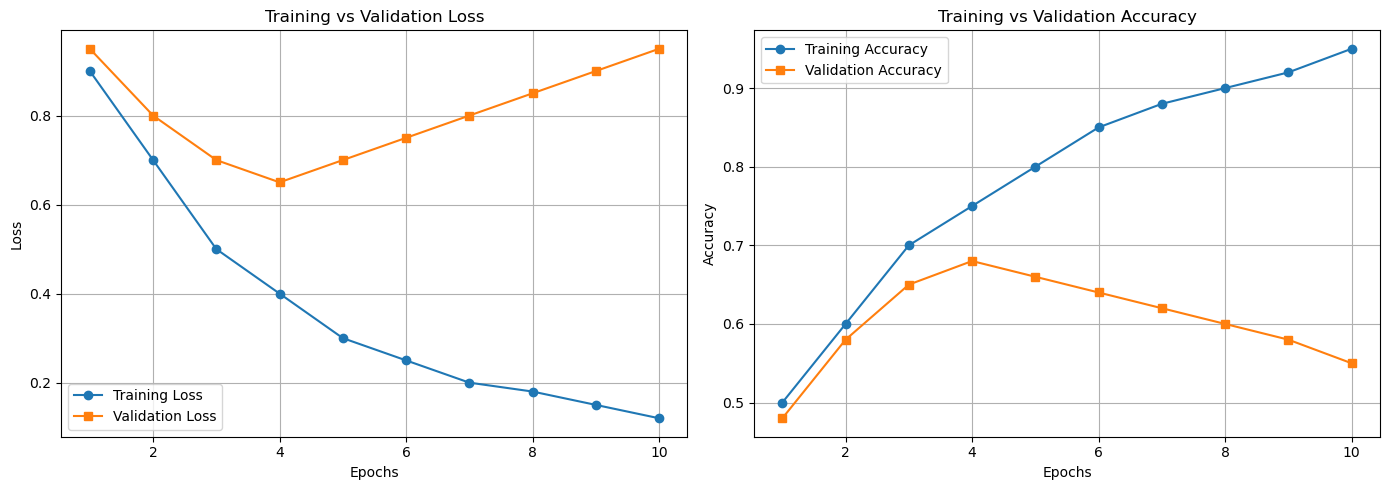

In [11]:
# Provided training history data
training_epochs = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

train_loss = [0.9, 0.7, 0.5, 0.4, 0.3, 0.25, 0.2, 0.18, 0.15, 0.12]
val_loss = [0.95, 0.8, 0.7, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]

train_acc = [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.88, 0.9, 0.92, 0.95]
val_acc = [0.48, 0.58, 0.65, 0.68, 0.66, 0.64, 0.62, 0.6, 0.58, 0.55]

# Setting up the figure for subplots
plt.figure(figsize=(14, 5))

# Plot 1: Training vs Validation Loss
plt.subplot(1, 2, 1)
plt.plot(training_epochs, train_loss, label='Training Loss', marker='o')
plt.plot(training_epochs, val_loss, label='Validation Loss', marker='s')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

# Plot 2: Training vs Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(training_epochs, train_acc, label='Training Accuracy', marker='o')
plt.plot(training_epochs, val_acc, label='Validation Accuracy', marker='s')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

1) The model is `overfitting`.
2) We can clearly see overfitting characteristics in the plotted learning curves. While the training loss continues to drop and training accuracy climbs (approaching 0.95), the validation loss starts to increase significantly after epoch 4, and validation accuracy degrades. Overfitting occurs when the model starts learning statistical noise instead of actual patterns, leading to poor generalization on unseen data.
3) To improve this model's performance, we can use two techniques mentioned: `Dropout` and `Early Stopping`.

## Task 2: Overfitting Reduction using Dropout

In [15]:
# Preparing dataset
np.random.seed(42)
X = np.random.rand(1000, 10)
y = (np.sum(X, axis=1) > 5).astype(int)

print(X.shape, X[:5])
print(y.shape, y[:5])

(1000, 10) [[0.37454012 0.95071431 0.73199394 0.59865848 0.15601864 0.15599452
  0.05808361 0.86617615 0.60111501 0.70807258]
 [0.02058449 0.96990985 0.83244264 0.21233911 0.18182497 0.18340451
  0.30424224 0.52475643 0.43194502 0.29122914]
 [0.61185289 0.13949386 0.29214465 0.36636184 0.45606998 0.78517596
  0.19967378 0.51423444 0.59241457 0.04645041]
 [0.60754485 0.17052412 0.06505159 0.94888554 0.96563203 0.80839735
  0.30461377 0.09767211 0.68423303 0.44015249]
 [0.12203823 0.49517691 0.03438852 0.9093204  0.25877998 0.66252228
  0.31171108 0.52006802 0.54671028 0.18485446]]
(1000,) [1 0 0 1 0]


Training Base Model with no Dropout
Training Model with Dropout
Final Validation Accuracy (No Dropout): 0.9450
Final Validation Accuracy (With Dropout): 0.9100


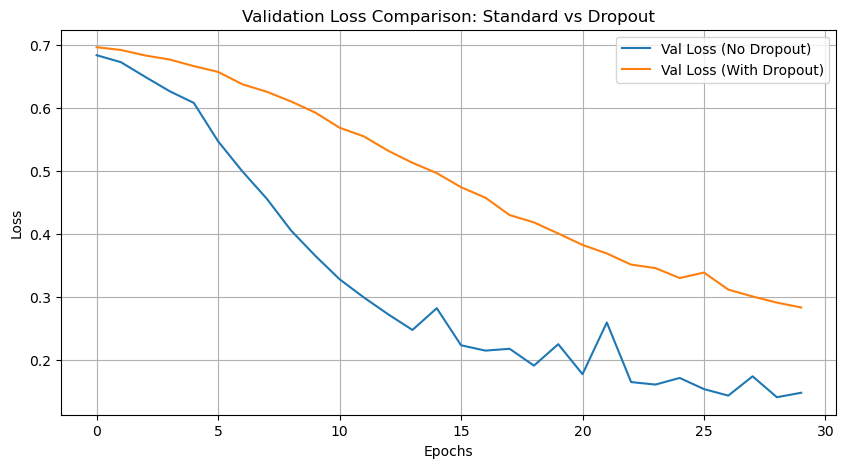

In [19]:
# Building and training model without dropout
print("Training Base Model with no Dropout")
base_model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(10,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

base_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_base = base_model.fit(X, y, epochs=30, batch_size=32, validation_split=0.2, verbose=0)

# Building and training model with dropout
print("Training Model with Dropout")
dropout_model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(10,)),
    tf.keras.layers.Dropout(0.5), # Drop 50% of neurons randomly
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.3), # Drop 30% of neurons
    tf.keras.layers.Dense(1, activation='sigmoid')
])

dropout_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_drop = dropout_model.fit(X, y, epochs=30, batch_size=32, validation_split=0.2, verbose=0)

# Displaying & Comparing Results
final_acc_base = history_base.history['val_accuracy'][-1]
final_acc_drop = history_drop.history['val_accuracy'][-1]

print(f"Final Validation Accuracy (No Dropout): {final_acc_base:.4f}")
print(f"Final Validation Accuracy (With Dropout): {final_acc_drop:.4f}")

# Plotting Loss Curves for comparison
plt.figure(figsize=(10, 5))
plt.plot(history_base.history['val_loss'], label='Val Loss (No Dropout)')
plt.plot(history_drop.history['val_loss'], label='Val Loss (With Dropout)')
plt.title('Validation Loss Comparison: Standard vs Dropout')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

1) In overfitting, neurons can form complex co-adaptations where one unit changes to fix the mistakes of another. Dropout prevents these co-adaptations by temporarily and randomly removing nodes during training. This forces the network to take a probabilistic approach, distributing responsibility across layers and resulting in a more generalized model that doesn't rely too heavily on specific pathways.
2) If the dropout rate is set too high (e.g., dropping 90% of neurons), the network loses too much learning capacity. This leads to `underfitting`, where the model becomes too simple and fails to capture patterns even in the training data itself.

## Task 3: K-Fold Cross Validation

In [27]:
# Loading data
iris_data = load_iris()
X, y = iris_data.data, iris_data.target

# For my Understanding
print(X.shape)
print(y.shape)

k_folder = KFold(n_splits=5, shuffle=True, random_state=42)
for train_idx, test_idx in k_folder.split(X):
    print(train_idx)
    print(test_idx)

(150, 4)
(150,)
[  0   1   2   3   4   5   6   7   8  10  11  13  14  15  16  17  20  21
  22  23  24  25  27  28  32  33  34  35  37  38  39  40  41  42  43  44
  46  47  48  49  50  51  52  53  54  57  58  59  60  61  62  63  65  66
  67  70  71  72  74  75  77  79  80  81  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 105 106 107 109 111
 112 113 114 115 116 117 119 120 121 122 123 124 125 126 129 130 133 134
 135 136 137 138 139 140 142 144 146 147 148 149]
[  9  12  18  19  26  29  30  31  36  45  55  56  64  68  69  73  76  78
  82 104 108 110 118 127 128 131 132 141 143 145]
[  1   2   3   5   6   7   8   9  12  13  14  17  18  19  20  21  23  24
  25  26  29  30  31  33  34  35  36  37  38  39  41  43  45  46  47  48
  49  50  52  53  54  55  56  57  58  59  61  62  63  64  68  69  70  71
  72  73  74  76  77  78  79  80  82  83  84  87  88  89  90  91  92  93
  94  95  97  98  99 100 101 102 103 104 106 107 108 110 111 112 113 114
 115 116

In [26]:
# Method 1: Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf_split = LogisticRegression(max_iter=200)
clf_split.fit(X_train, y_train)
split_preds = clf_split.predict(X_test)
split_accuracy = accuracy_score(y_test, split_preds)

print("80/20 Train-Test Split")
print(f"Accuracy: {split_accuracy:.4f}\n")

# Method 2: 5-Fold Cross Validation
k_folder = KFold(n_splits=5, shuffle=True, random_state=42)
clf_cv = LogisticRegression(max_iter=200)
fold_accuracies = []

print("5-Fold Cross Validation")
fold_num = 1
for train_idx, test_idx in k_folder.split(X):
    X_train_cv, X_test_cv = X[train_idx], X[test_idx]
    y_train_cv, y_test_cv = y[train_idx], y[test_idx]
    
    clf_cv.fit(X_train_cv, y_train_cv)
    cv_preds = clf_cv.predict(X_test_cv)
    fold_acc = accuracy_score(y_test_cv, cv_preds)
    
    fold_accuracies.append(fold_acc)
    print(f"Fold {fold_num} Accuracy: {fold_acc:.4f}")
    fold_num += 1

print(f"\nAverage CV Accuracy: {np.mean(fold_accuracies):.4f}")

80/20 Train-Test Split
Accuracy: 1.0000

5-Fold Cross Validation
Fold 1 Accuracy: 1.0000
Fold 2 Accuracy: 1.0000
Fold 3 Accuracy: 0.9333
Fold 4 Accuracy: 0.9667
Fold 5 Accuracy: 0.9667

Average CV Accuracy: 0.9733


1) The K-Fold Cross Validation is much more reliable. By averaging results over multiple iterations, it provides a robust evaluation and reduces the variance and bias that can happen with a single, lucky (or unlucky) train-test split.
2) It maximizes the efficient use of limited data. Every single data point gets a chance to be in both the training set and the testing set across the different folds, ensuring a comprehensive evaluation without needing to sacrifice a large portion of the dataset exclusively for testing.

## Task 4: Early Stopping Implementation

Training standard model for 50 epochs...


/home/luc/miniconda3/envs/jupyter/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training model with Early Stopping...

Results
Standard Model - Epochs executed: 50 | Final Val Accuracy: 0.9400
Early Stop Model - Epochs executed: 50 | Final Val Accuracy: 0.9200


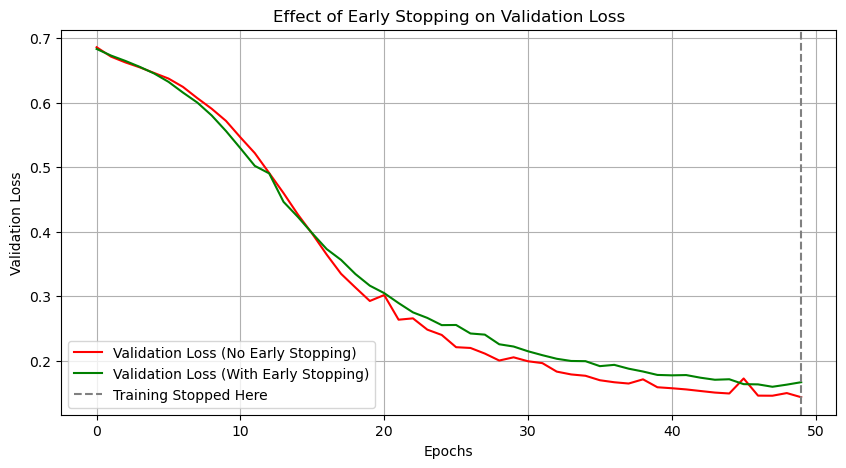

In [28]:
# Preparing Dataset
np.random.seed(99) # By providing this random seed anyone can produce the same results because it specifies the order and values of random values in np.random.rand(rows, cols)
X = np.random.rand(1000, 10)
y = (np.sum(X, axis=1) > 5).astype(int)

# Helper function to build model
def create_simple_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(32, activation='relu', input_shape=(10,)),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Training without Early Stopping
print("Training standard model for 50 epochs...")
model_standard = create_simple_model()
history_std = model_standard.fit(X, y, epochs=50, validation_split=0.2, verbose=0)

# Training with Early Stopping
print("Training model with Early Stopping...")
model_early = create_simple_model()
early_stop_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True
)

history_early = model_early.fit(
    X, y, 
    epochs=50, 
    validation_split=0.2, 
    callbacks=[early_stop_callback], 
    verbose=0
)

# Displaying Results
epochs_run = len(history_early.history['loss'])
val_acc_std = history_std.history['val_accuracy'][-1]
val_acc_early = history_early.history['val_accuracy'][-1]

print("\nResults")
print(f"Standard Model - Epochs executed: 50 | Final Val Accuracy: {val_acc_std:.4f}")
print(f"Early Stop Model - Epochs executed: {epochs_run} | Final Val Accuracy: {val_acc_early:.4f}")

# Plotting Loss Curves
plt.figure(figsize=(10, 5))
plt.plot(history_std.history['val_loss'], label='Validation Loss (No Early Stopping)', color='red')
plt.plot(history_early.history['val_loss'], label='Validation Loss (With Early Stopping)', color='green')
plt.axvline(x=epochs_run-1, color='gray', linestyle='--', label='Training Stopped Here')

plt.title('Effect of Early Stopping on Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

1) Early stopping monitors the validation set and halts training exactly when overfitting signs appear. This prevents the model from blindly continuing to memorize the training data while its performance degrades on unseen data. Because it restores the best weights, it essentially captures the model at its peak optimal validation state.
2) The patience parameter dictates the number of epochs the training process will wait for an improvement in the monitored metric before terminating. This helps prevent the training from stopping too prematurely due to a tiny, temporary spike in validation loss.

## Task 5: Combined Generalization Improvement

In [ ]:
# Dataset
np.random.seed(123)
X = np.random.rand(1200, 12)
y = (np.sum(X, axis=1) > 6).astype(int)

# Training Baseline Model
print("Baseline Model")
model_base = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(12,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model_base.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
hist_base = model_base.fit(X, y, epochs=40, validation_split=0.2, verbose=0)

print(f"Baseline Training Acc: {hist_base.history['accuracy'][-1]:.4f}")
print(f"Baseline Validation Acc: {hist_base.history['val_accuracy'][-1]:.4f}\n")


# Training Model with Dropout and Early Stopping
print("Model with Dropout & Early Stopping")
model_opt = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(12,)),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model_opt.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stopper = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
hist_opt = model_opt.fit(X, y, epochs=40, validation_split=0.2, callbacks=[early_stopper], verbose=0)

print(f"Optimized Training Acc: {hist_opt.history['accuracy'][-1]:.4f}")
print(f"Optimized Validation Acc: {hist_opt.history['val_accuracy'][-1]:.4f}\n")


# Applying 5-Fold Cross Validation on the Optimized Architecture
print("5-Fold CV on Optimized Architecture")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = []
fold = 1

for train_idx, test_idx in kf.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # Re-instantiate model for each fold
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation='relu', input_shape=(12,)),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    # We apply early stopping inside CV as well
    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
    model.fit(X_train, y_train, epochs=40, validation_split=0.1, callbacks=[early_stop], verbose=0)
    
    # Evaluate on the test fold
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    scores.append(test_accuracy)
    print(f"Fold {fold} Accuracy: {test_accuracy:.4f}")
    fold += 1

print(f"\nMean 5-Fold CV Accuracy: {np.mean(scores):.4f}")

Baseline Model


/home/luc/miniconda3/envs/jupyter/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Baseline Training Acc: 0.9760
Baseline Validation Acc: 0.9375

Model with Dropout & Early Stopping
Optimized Training Acc: 0.8750
Optimized Validation Acc: 0.9292

5-Fold CV on Optimized Architecture
Fold 1 Accuracy: 0.9167
Fold 2 Accuracy: 0.9625
Fold 3 Accuracy: 0.8917
Fold 4 Accuracy: 0.9125
Fold 5 Accuracy: 0.9417

Mean 5-Fold CV Accuracy: 0.9250


1) In this run, Dropout combined with Early Stopping proved most effective. While the baseline model achieved a high training accuracy of 97.6%, the gap between training and validation (93.75%) indicated overfitting. The optimized model reduced this gap (87.5% training vs 92.9% validation), showing that the model is no longer simply memorizing noise but is actually learning features that generalize better to new data.
2) Combining techniques is highly effective because they tackle generalization issues from different angles.
    1) Dropout acts as a regularization method that actively restructures the network dynamically to prevent overfitting during individual epochs by ensuring no single neuron becomes overly reliant on specific inputs.
    2) Early stopping acts as a failsafe on the timeline, preventing the network from training past its optimal point and stopping before it begins to model the noise in the training set.
    3) Cross-validation acts as a diagnostic tool, providing a robust, variance-reduced estimate (as seen in our mean accuracy of 92.5%) of how this optimized model actually performs across different subsets of data.